In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy.linalg as la

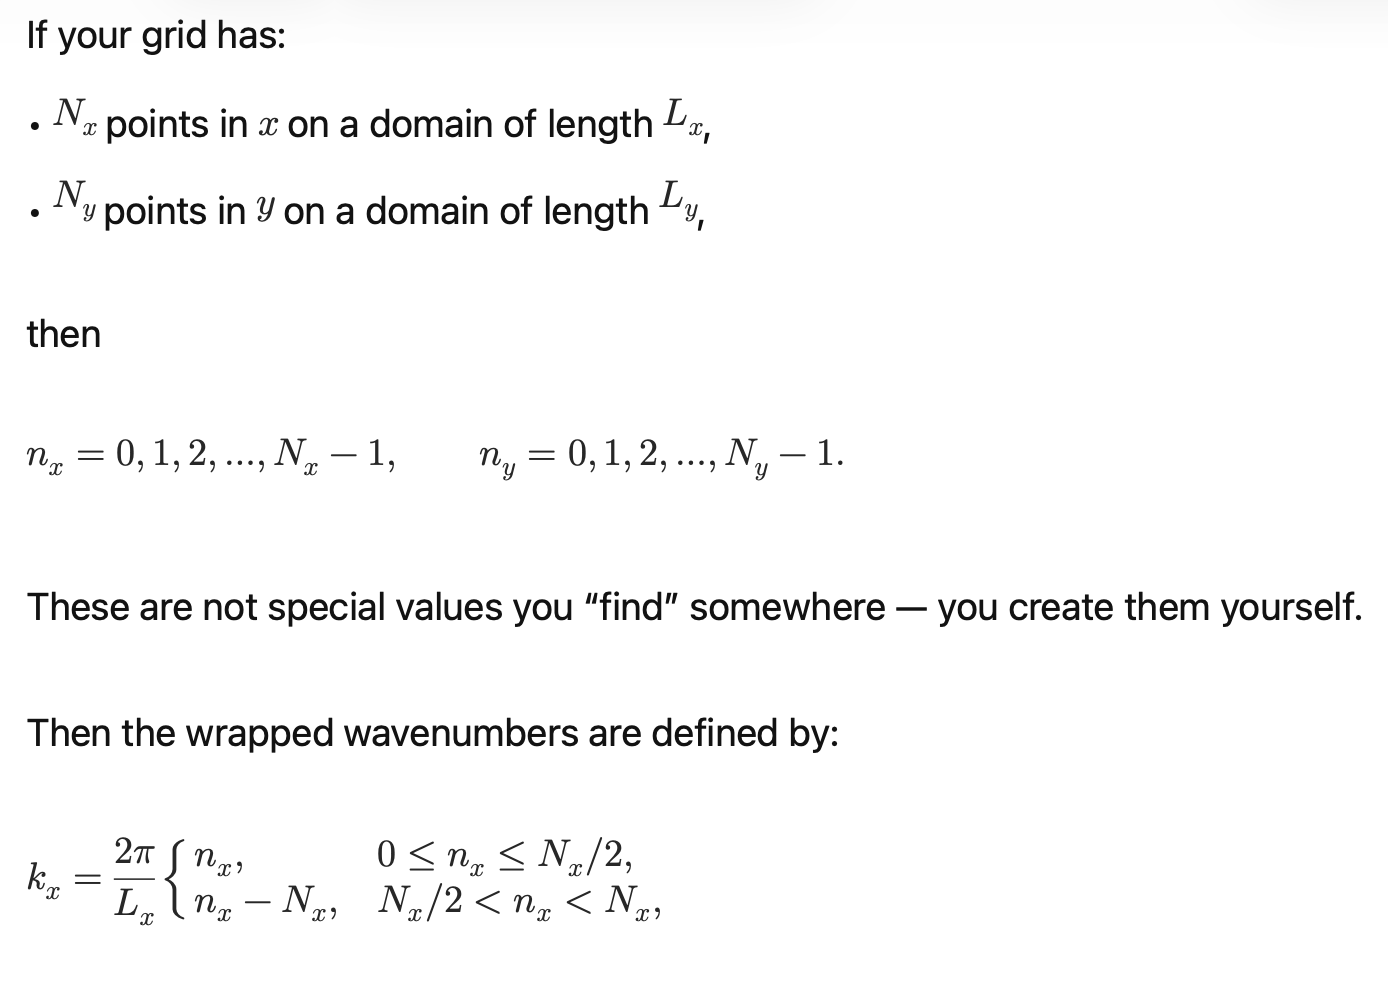

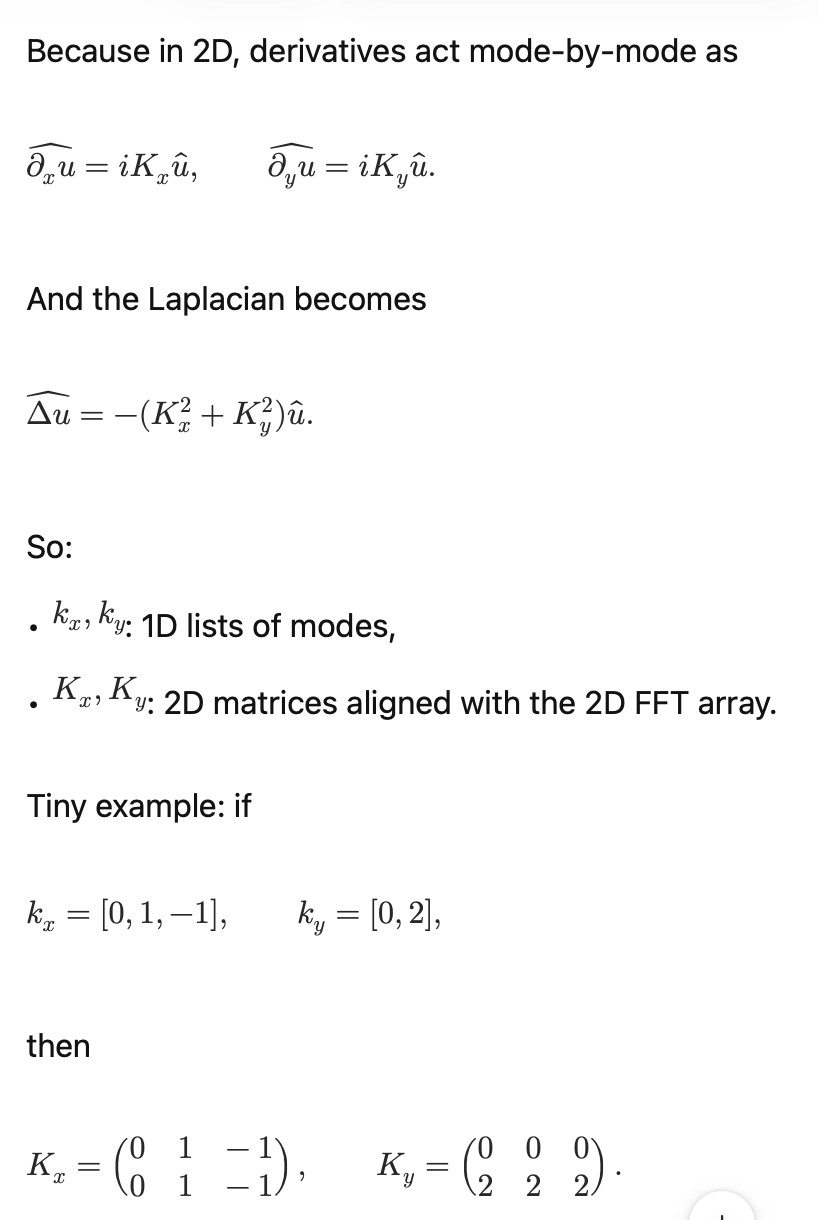

In [ ]:
# Exercise - 5.1

# Domain 
L_x = 2*np.pi
L_y = 2*np.pi
N_x = 256
N_y = 256

# 2D periodic grid
del_x = L_x/N_x
del_y = L_y/N_y
x_j = np.arange(N_x) * del_x
y_j = np.arange(N_y) * del_y
X, Y = np.meshgrid(x_j, y_j, indexing='xy')

# Wrapped wavenumber arrays
n_x = np.arange(N_x)
n_y = np.arange(N_y)
k_x = (2*np.pi/L_x) * np.where(n_x <= N_x/2, n_x, n_x - N_x)
k_y = (2*np.pi/L_y) * np.where(n_y <= N_y/2, n_y, n_y - N_y)
Kx, Ky = np.meshgrid(k_x, k_y, indexing='xy')

In [15]:
error_table = pd.DataFrame(columns = ['N','(m,n)','error_02_inf','error_02_l2'])

def f(m,x,n,y):
    return np.sin(m*x)*np.cos(n*y)

# Analytic derivatives
def f_x(m,x,n,y):
    return m*np.cos(m*x)*np.cos(n*y)
def f_y(m,x,n,y):
    return -n*np.sin(m*x)*np.sin(n*y)
def nabla_f(m,x,n,y):
    return -(m**2+n**2)*np.sin(m*x)*np.cos(n*y)

# Spectral derivatives
def f_hat_x(f_hat,Kx):
    return 1j * Kx * f_hat
def f_hat_y(f_hat,Ky):
    return 1j * Ky * f_hat
def nabla_f_hat(f_hat,Kx,Ky):
    return -(Kx**2+Ky**2)*f_hat

for (N_x,N_y) in [(16,16),(32,32),(64,64),(128,128),(256,256)]:
    for (m,n) in [(1,1),(2,3),(4,2)]:
        # 2D periodic grid
        del_x = L_x/N_x
        del_y = L_y/N_y
        x_j = np.arange(N_x) * del_x
        y_j = np.arange(N_y) * del_y
        X, Y = np.meshgrid(x_j, y_j, indexing='xy')

        # Wrapped wavenumber arrays
        n_x = np.arange(N_x)
        n_y = np.arange(N_y)
        k_x = (2*np.pi/L_x) * np.where(n_x <= N_x//2, n_x, n_x - N_x)
        k_y = (2*np.pi/L_y) * np.where(n_y <= N_y//2, n_y, n_y - N_y)
        Kx, Ky = np.meshgrid(k_x, k_y, indexing='xy')

        error_02 = nabla_f(m,X,n,Y) - np.fft.ifft2(nabla_f_hat(np.fft.fft2(f(m,X,n,Y)),Kx,Ky)).real
        error_02_l2 = np.sqrt(1/(N_x*N_y)*np.sum(np.sum(np.abs(error_02)**2)))
        error_02_inf = np.max(np.abs(error_02))

        error_table.loc[len(error_table)] = [N_x, (m,n),error_02_inf,error_02_l2]


In [16]:
error_table

,N,"(m,n)",error_02_inf,error_02_l2
0,16,"(1, 1)",1.443290e-14,3.949460e-15
1,16,"(2, 3)",6.217249e-14,1.784896e-14
2,16,"(4, 2)",2.842171e-14,5.278327e-15
3,32,"(1, 1)",7.271961e-14,1.754516e-14
4,32,"(2, 3)",1.474376e-13,3.637285e-14
5,32,"(4, 2)",1.207923e-13,3.589392e-14
6,64,"(1, 1)",3.441691e-13,8.692358e-14
7,64,"(2, 3)",1.291411e-12,2.538162e-13
8,64,"(4, 2)",7.531753e-13,2.092983e-13
9,128,"(1, 1)",1.503464e-12,3.366136e-13


In [5]:
# Exercise 5.2

# Initial condition
def u_0(x,y):
    return np.sin(x)*np.cos(y) + (0.5) * np.cos(2*x) * np.sin(3*y)

# Domain 
L_x = 2*np.pi
L_y = 2*np.pi
N_x = 128
N_y = 128

# 2D periodic grid
del_x = L_x/N_x
del_y = L_y/N_y
x_j = np.arange(N_x) * del_x
y_j = np.arange(N_y) * del_y
X, Y = np.meshgrid(x_j, y_j, indexing='xy')

# Wrapped wavenumber arrays
n_x = np.arange(N_x)
n_y = np.arange(N_y)
k_x = (2*np.pi/L_x) * np.where(n_x <= N_x//2, n_x, n_x - N_x)
k_y = (2*np.pi/L_y) * np.where(n_y <= N_y//2, n_y, n_y - N_y)
Kx, Ky = np.meshgrid(k_x, k_y, indexing='xy')

# Time 
T = 0.9
nu = 0.5

u_hat_0 = np.fft.fft2(u_0(X,Y))
u_hat = lambda t: np.exp(-nu * (Kx**2 + Ky**2) * t) * u_hat_0
u_real = lambda u_hat: np.fft.ifft2(u_hat).real

# Analytic reference fields
def analytic_ref(x,y,t):
    return np.exp(-nu * (1**2 + 1**2) * t) * np.sin(x)*np.cos(y) + (0.5) * np.exp(-nu * (2**2 + 3**2) * t) * np.cos(2*x) * np.sin(3*y)

snapshot_dict = dict()
final_table = pd.DataFrame(columns = ['t','E(t)'])

for t in [0,T/2,T]:
    u_fft = u_real(u_hat(t))
    snapshot_dict[t] = u_fft

# Error
error = u_real(u_hat(T)) - analytic_ref(X,Y,T)

# Error norm - l2
error_l2 = np.sqrt((1/(N_x*N_y)) * np.sum(np.sum(np.abs(error)**2)))
print(f"Error - L2: {error_l2}")
# Error norm - inf
error_inf = np.max(np.abs(error))
print(f"Error - inf: {error_inf}")

for t in np.linspace(0,T,100):
    # Energy, E(t)
    E_t = (1/(N_x*N_y)) * np.sum(np.abs(u_real(u_hat(t)))**2)

    final_table.loc[len(final_table)] = [t,E_t]

Error - L2: 6.759780025840069e-17
Error - inf: 2.7755575615628914e-16


In [6]:
final_table

,t,E(t)
0,0.000000,0.312500
1,0.009091,0.301029
2,0.018182,0.290416
3,0.027273,0.280572
4,0.036364,0.271420
...,...,...
95,0.863636,0.044443
96,0.872727,0.043642
97,0.881818,0.042856
98,0.890909,0.042084


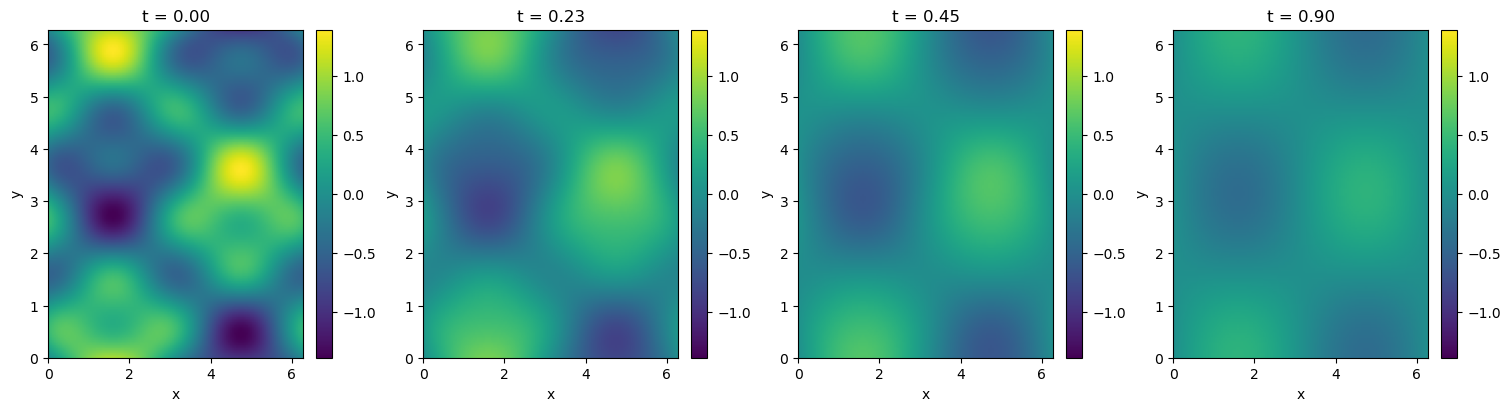

In [26]:
times_snap = [0, T/4, T/2, T]

for t in times_snap:
    u_fft = u_real(u_hat(t))
    snapshot_dict[t] = u_fft

all_vals = np.concatenate([snapshot_dict[t].ravel() for t in times_snap])
vmin = all_vals.min()
vmax = all_vals.max()

fig, ax = plt.subplots(1, 4, figsize=(15, 4), constrained_layout=True)

for i, t in enumerate(times_snap):
    im = ax[i].imshow(
        snapshot_dict[t],
        extent=[0, L_x, 0, L_y],
        origin='lower',
        aspect='auto',
        vmin=vmin,
        vmax=vmax
    )
    ax[i].set_title(f"t = {t:.2f}")
    ax[i].set_xlabel("x")
    ax[i].set_ylabel("y")
    fig.colorbar(im, ax=ax[i])

plt.show()

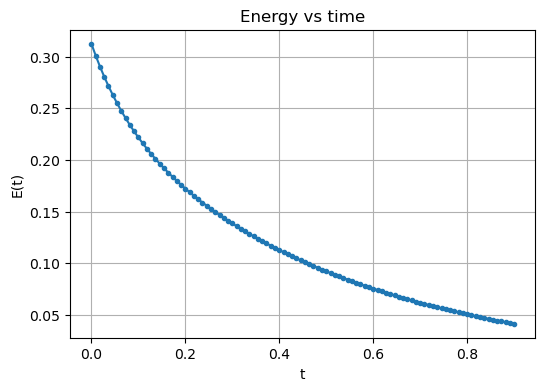

In [8]:
# --- Energy vs time plot ---
plt.figure(figsize=(6,4))
plt.plot(final_table['t'], final_table['E(t)'], marker='o', markersize=3)
plt.xlabel("t")
plt.ylabel("E(t)")
plt.title("Energy vs time")
plt.grid(True)
plt.show()

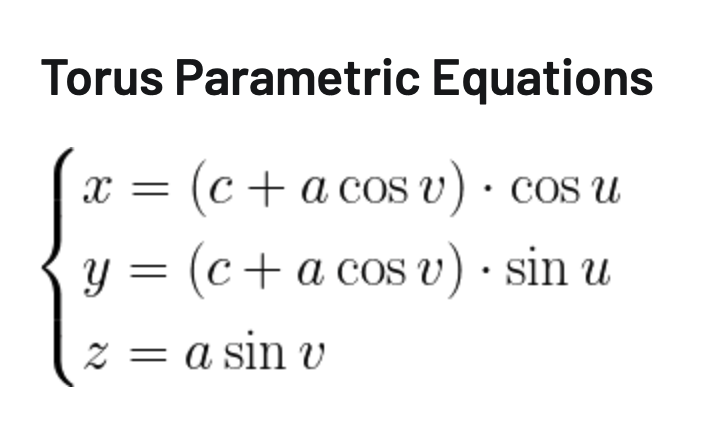

In [37]:
# Exercise 5.3 - 2D Poisson Solver on the Torus

# Initial condition
def phi(x,y):
    return np.sin(y)*np.cos(x)

# Domain 
L_x = 2*np.pi
L_y = 2*np.pi
N_x = 128
N_y = 128

# 2D periodic grid
x_j = np.arange(N_x) * (L_x / N_x)
y_j = np.arange(N_y) * (L_y / N_y)
X, Y = np.meshgrid(x_j, y_j, indexing='xy')

# Wrapped wavenumber arrays
n_x = np.arange(N_x)
n_y = np.arange(N_y)
k_x = (2*np.pi/L_x) * np.where(n_x <= N_x//2, n_x, n_x - N_x)
k_y = (2*np.pi/L_y) * np.where(n_y <= N_y//2, n_y, n_y - N_y)
Kx, Ky = np.meshgrid(k_x, k_y, indexing='xy')


In [ ]:
def known_solution(x,y):
    return np.cos(x)*np.sin(y)

def forcing(x, y):
    return 2 * np.cos(x) * np.sin(y)

f_on_grid = forcing(X,Y)
f_hat = np.fft.fft2(f_on_grid)

# Spectral solution
phi_hat = np.zeros_like(f_hat, dtype=complex)
denominator = Kx**2 + Ky**2
phi_hat[Kx**2 + Ky**2 != 0] = f_hat[Kx**2 + Ky**2 != 0]/denominator[denominator != 0]
phi_inv = np.fft.ifft2(phi_hat).real

# Error
error = phi_inv - known_solution(X,Y)
# Error norm - l2
error_l2 = np.sqrt((1/(N_x*N_y)) * np.sum(np.sum(np.abs(error)**2)))
print(f"Error - L2: {error_l2}")
# Error norm - inf
error_inf = np.max(np.abs(error))
print(f"Error - inf: {error_inf}")

Error - L2: 1.6599812991088463e-16
Error - inf: 6.661338147750939e-16


In [ ]:
# Initial condition
def phi(x,y):
    return np.sin(y)*np.cos(x)

def known_solution(x,y):
    return np.cos(x)*np.sin(y)

def forcing(x, y):
    return 2 * np.cos(x) * np.sin(y)

# Domain 
L_x = 2*np.pi
L_y = 2*np.pi

summary_table = pd.DataFrame(columns = ['N','Error_L2','Error_inf'])

resolutions = [64,128,256,512,1024]
for N in resolutions:
    N_x,N_y = N,N

    # 2D periodic grid
    x_j = np.arange(N_x) * (L_x / N_x)
    y_j = np.arange(N_y) * (L_y / N_y)
    X, Y = np.meshgrid(x_j, y_j, indexing='xy')

    # Wrapped wavenumber arrays
    n_x = np.arange(N_x)
    n_y = np.arange(N_y)
    k_x = (2*np.pi/L_x) * np.where(n_x <= N_x//2, n_x, n_x - N_x)
    k_y = (2*np.pi/L_y) * np.where(n_y <= N_y//2, n_y, n_y - N_y)
    Kx, Ky = np.meshgrid(k_x, k_y, indexing='xy')

    f_on_grid = forcing(X,Y)
    f_hat = np.fft.fft2(f_on_grid)

    # Spectral solution
    phi_hat = np.zeros_like(f_hat, dtype=complex)
    denominator = Kx**2 + Ky**2
    phi_hat[Kx**2 + Ky**2 != 0] = f_hat[Kx**2 + Ky**2 != 0]/denominator[denominator != 0]
    phi_inv = np.fft.ifft2(phi_hat).real

    # Error
    error = phi_inv - known_solution(X,Y)
    # Error norm - l2
    error_l2 = np.sqrt((1/(N_x*N_y)) * np.sum(np.sum(np.abs(error)**2)))
    print(f"Error - L2: {error_l2}")
    # Error norm - inf
    error_inf = np.max(np.abs(error))
    print(f"Error - inf: {error_inf}")

    summary_table.loc[len(summary_table)] = [N,error_l2,error_inf]
    

Error - L2: 1.6232386989523147e-16
Error - inf: 5.551115123125783e-16
Error - L2: 1.6599812991088463e-16
Error - inf: 6.661338147750939e-16
Error - L2: 1.582674951769837e-16
Error - inf: 7.771561172376096e-16
Error - L2: 1.681299801223684e-16
Error - inf: 8.881784197001252e-16
Error - L2: 1.7444673936943328e-16
Error - inf: 8.881784197001252e-16


In [4]:
summary_table

,N,Error_L2,Error_inf
0,64.0,1.623239e-16,5.551115e-16
1,128.0,1.659981e-16,6.661338e-16
2,256.0,1.582675e-16,7.771561e-16
3,512.0,1.681300e-16,8.881784e-16
4,1024.0,1.744467e-16,8.881784e-16


/var/folders/wd/trxjsq491pnd_0jjsv877_pm0000gn/T/ipykernel_6309/1703959857.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


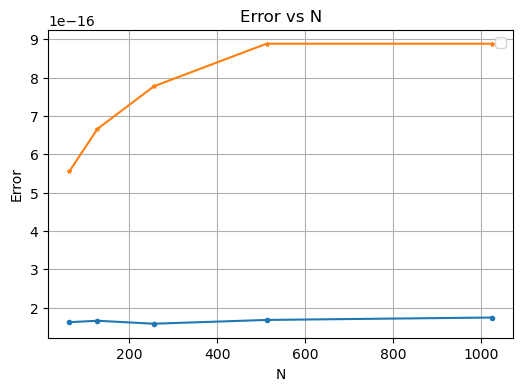

In [7]:
# --- Error vs N plot ---
plt.figure(figsize=(6,4))
plt.plot(summary_table['N'], summary_table['Error_L2'], marker='o', markersize=3)
plt.plot(summary_table['N'], summary_table['Error_inf'], marker='*', markersize=3)
plt.xlabel("N")
plt.ylabel("Error")
plt.title("Error vs N")
plt.grid(True)
plt.legend()
plt.show()